In [1]:
# IROS optimisation by hand - SCOX-1

from singleCAM_IROS._pipeline_support import _handle_dirpaths

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import shift2pos, shift2angle, angle2shift, equatorial2shift
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask, count, decode
from bloodmoon.optim import model_sky as bm_sky

import darksun as ds
from darksun.data import DataLoader, CatalogueLoader

from fract_shift2 import model_shadowgram


def extract_catalogue_angular_coords(
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    """
    s, txs, tys = [], [], []
    for sourceID in np.unique(catalogue.DLdata['ID']):
        source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)]
        sx, sy = equatorial2shift(sdl, camera, source['RA'][0], source['DEC'][0])
        #sx, sy = equatorial2shift(sdl, camera, source['RA'][0], source['DEC'][0])
        thetax, thetay = map(lambda x: shift2angle(wfm, x), (sx, sy))
        s.append(sourceID)
        txs.append(thetax)
        tys.append(thetay)

    df = pd.DataFrame(
        {'ID': s, 'THETAX': txs, 'THETAY': tys}
    )
    return df

def model_sky(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    fluence: float,
    vignetting: bool = True,
    psfy: bool = True,
    bkg: NDArray | None = None,
) -> NDArray:
    """
    Generate a model of the reconstructed sky image for a point source.
    """
    detector = model_shadowgram(
        camera, shift_x, shift_y, vignetting=vignetting, psfy=psfy,
    ) * fluence
    if bkg is not None:
        detector += bkg
    return decode(camera, detector)


skyfield = "IROSDummy"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
#mask_FITS = "wfm_mask_summer2021.fits"
data_FITS = "scox1_2-50keV_mask_050_1040x17_1ks_infdet_opaquemask_newpathinmask"

#skyfield = "GalacticCentre"
#mask_FITS = "wfm_mask_NTHT_20250725.fits"
#data_FITS = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

mask_path, simul_data, _ = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)

#idx = 2
#source_ID = f's{idx}'
source_ID = 'scox1'

#from var import detector_solid_angle
#
#rng = np.random.default_rng()
#
#omega = detector_solid_angle(wfm)
#cxb_detector = omega / omega.sum() * rng.poisson(17400, (wfm.shape_detector)).sum() * wfm.bulk


from pathlib import Path

def savefig_to(
    figpath: str | Path,
    name: str,
    frmt: str = 'png',
) -> str | Path | None:
    """
    Creates the filepath to save a Figure with the chosen format,
    and checks if the file already exists. If the file exists,
    `None` is returned to avoid the file overwriting. 
    """
    def is_img(filepath: Path) -> bool:
        """Checks if a file has been already saved."""
        return filepath.is_file()
    
    filepath = f'{figpath}/{name}.{frmt}'
    if not is_img(Path(filepath)):
        return filepath
    return None

save_to = '/home/edoardo/Desktop/PSF_test'


SCOX1 angular coords: (np.float64(12.202274809914625), np.float64(21.025135698738143))



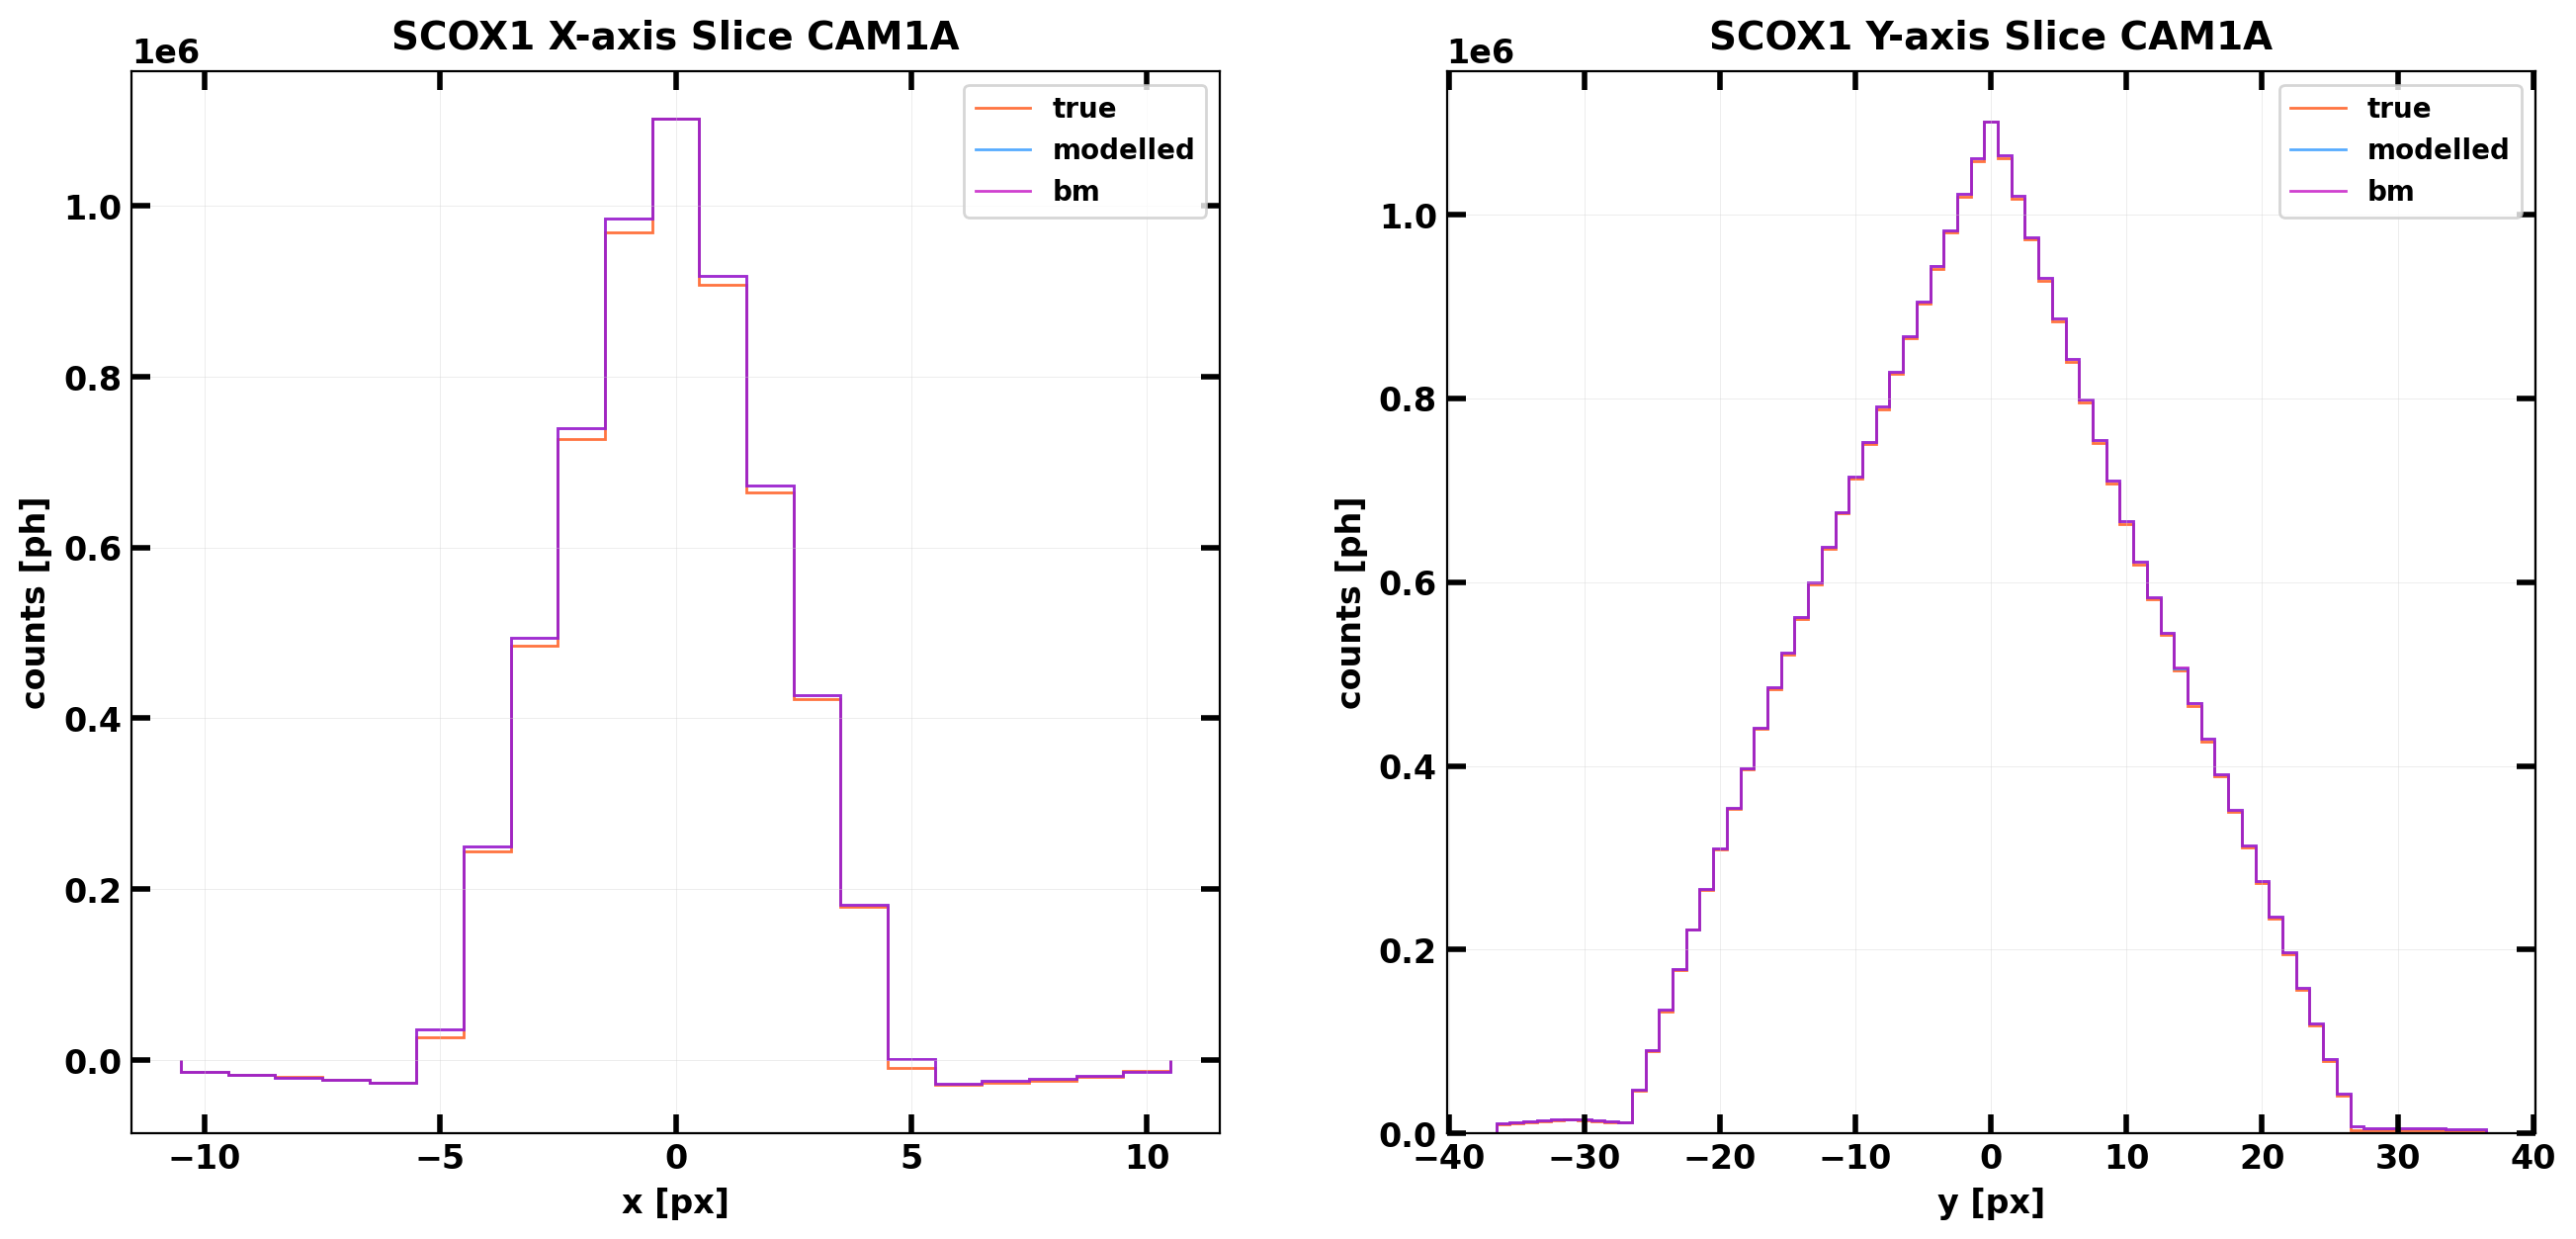

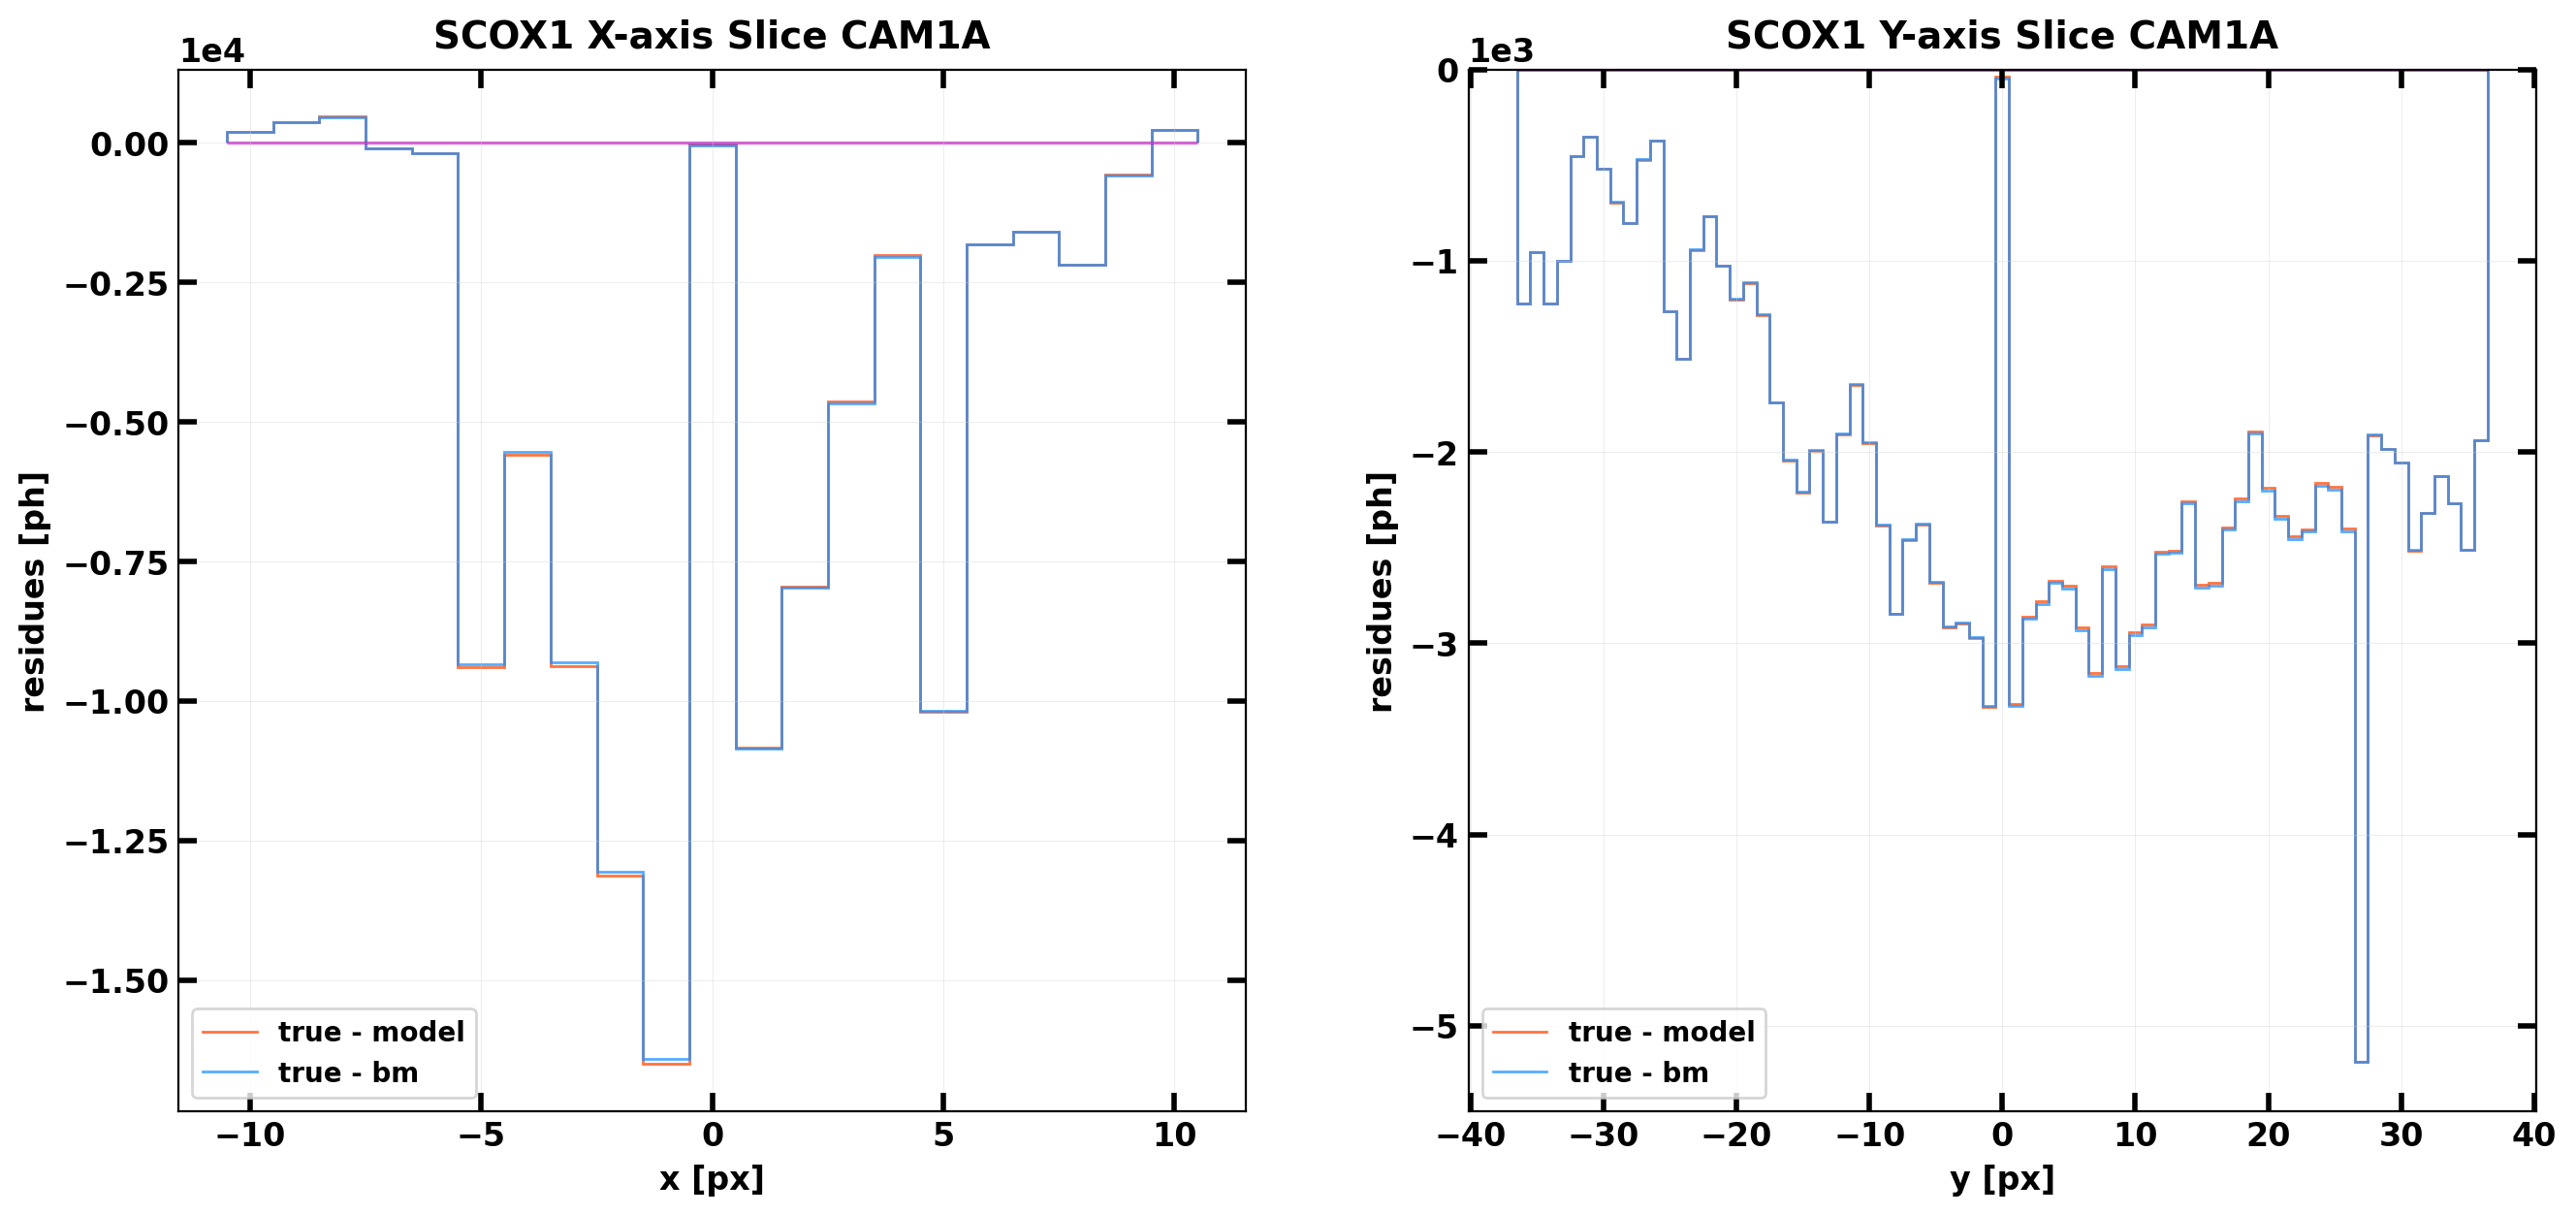

In [2]:
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#coords = tuple(
#    CoordEquatorial(ra, dec) for ra, dec in zip(catalogueA.DLdata['RA'], catalogueA.DLdata['DEC'])
#)
#coords_ = list(coords)
#coords_.pop(idx)
sdlA = ds.get_data(
    filepaths[cam_a][dataset],
    #coords=coords_,
)

detector, _ = count(wfm, sdlA.DLdata)
true_sky = decode(wfm, detector)

sources = extract_catalogue_angular_coords(catalogueA, sdlA, wfm)
lemxSource = sources[(sources['ID'] == source_ID)]

thetax, thetay = np.array(lemxSource['THETAX'])[0], np.array(lemxSource['THETAY'])[0]
print(f'\n{source_ID.upper()} angular coords: {thetax, thetay}\n')
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.018 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6])
#fluence = np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6]) + 1.25e4

pxdimy, pxdimx = (
    wfm.specs['mask_deltay'] / wfm.upscale_f.y,
    wfm.specs['mask_deltax'] / wfm.upscale_f.x,
)

lemxSource_model = model_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
lemxSource_bm_model = bm_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_sky = true_sky - lemxSource_model

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.slices_plot(
    sky=(true_sky, lemxSource_model, lemxSource_bm_model),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    labels=('true', 'modelled', 'bm'),
    cameraID=cam_a,
    save_to=savefig_to(save_to, f'skyslice_{source_ID}_{cam_a.upper()}' + '_newpathinmask'),
)
ds.slices_plot(
    sky=(res_sky, true_sky - lemxSource_bm_model, np.zeros(wfm.shape_sky)),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    ylabel='residues [ph]',
    labels=('true - model', 'true - bm', ''),
    cameraID=cam_a,
    save_to=savefig_to(save_to, f'skyslice_res_{source_ID}_{cam_a.upper()}' + '_newpathinmask'),
)
#ds.slices_plot(
#    sky=lemxSource_bm_model - lemxSource_model,
#    pos=(i, j),
#    crp=crp,
#    source=f'{source_ID.upper()} model',
#    ylabel='residues [ph]',
#    labels='bm - fshift',
#    cameraID=cam_a,
#    #save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
#)

In [3]:
from scipy.ndimage import center_of_mass
from bloodmoon.coords import pos2shift
from bloodmoon.images import argmax


def shifts_insight(
    camera: CodedMaskCamera,
    sky: NDArray,
    true_shifts: tuple[float, float],
) -> None:
    """Prints out source shifts (center of mass vs sky peak)."""
    yslit, xslit = (
        int(camera.specs['slit_deltay'] * camera.upscale_f.y / camera.specs['mask_deltay'] + 5),
        int(camera.specs['slit_deltax'] * camera.upscale_f.x / camera.specs['mask_deltax'] + 5),
    )
    labels = np.zeros(camera.shape_sky)
    labels[i - yslit : i + yslit + 1 , j - xslit : j + xslit + 1] = 1
    i_cm, j_cm = center_of_mass(sky, labels=labels, index=1)
    sx0, sy0 = camera.bins_sky.x[0], camera.bins_sky.y[0]
    ypxdim, xpxdim = (
        camera.specs['mask_deltay'] / camera.upscale_f.y,
        camera.specs['mask_deltax'] / camera.upscale_f.x,
    )
    sx_start, sy_start = sx0 + xpxdim * (j_cm - 1), sy0 + ypxdim * (i_cm - 1)
    sx_peak, sy_peak = pos2shift(camera, *argmax(sky))

    print(
        f'{source_ID.upper()} shifts: {true_shifts[0]}, {true_shifts[1]}\n'
        f'CM shifts: {sx_start}, {sy_start}\n'
        f'Peak shifts: {sx_peak}, {sy_peak}\n'
    )
    print(
        f'CM sigma (x, y): {abs(true_shifts[0] - sx_start) / xpxdim}, {abs(true_shifts[1] - sy_start) / ypxdim}\n'
        f'Peak sigma (x, y): {abs(true_shifts[0] - sx_peak) / xpxdim}, {abs(true_shifts[1] - sy_peak) / ypxdim}\n'
    )

shifts_insight(wfm, lemxSource_model, (shiftx, shifty))

SCOX1 shifts: 43.90940253074892, 78.04581352417019
CM shifts: 43.81784693018386, 76.87144014604712
Peak shifts: 43.89999999999998, 78.0

CM sigma (x, y): 1.8311120113011725, 2.348746756246129
Peak sigma (x, y): 0.188050614978863, 0.09162704834037072




SCOX1 angular coords: (np.float64(21.025135698738186), np.float64(-12.202274809914616))



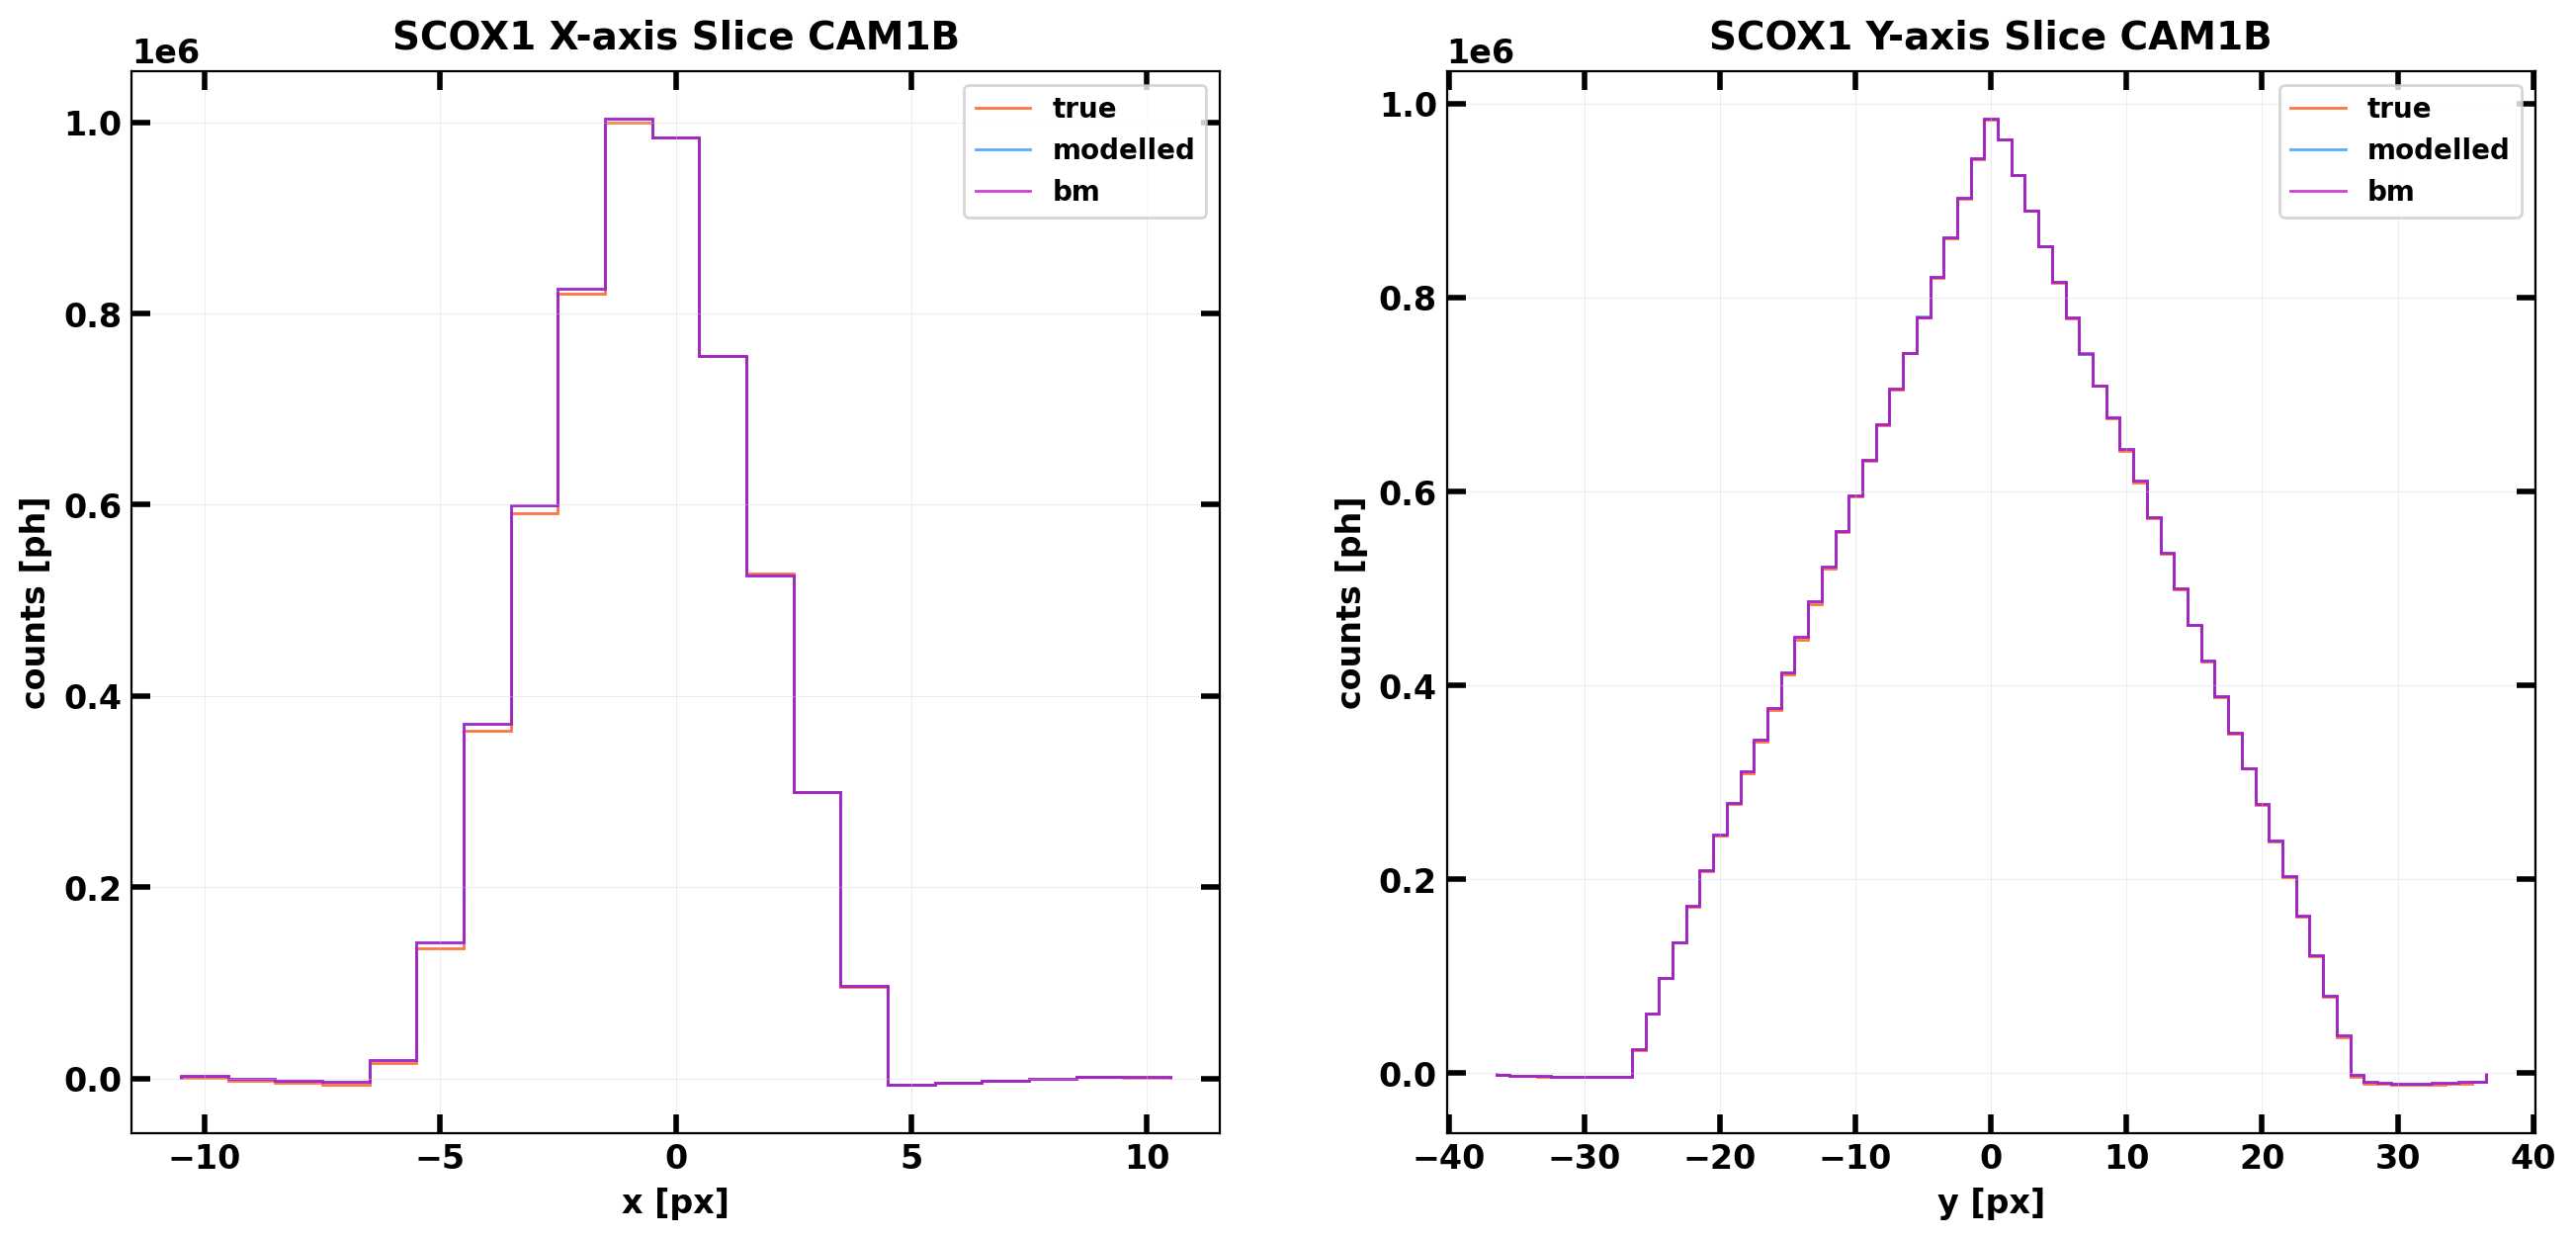

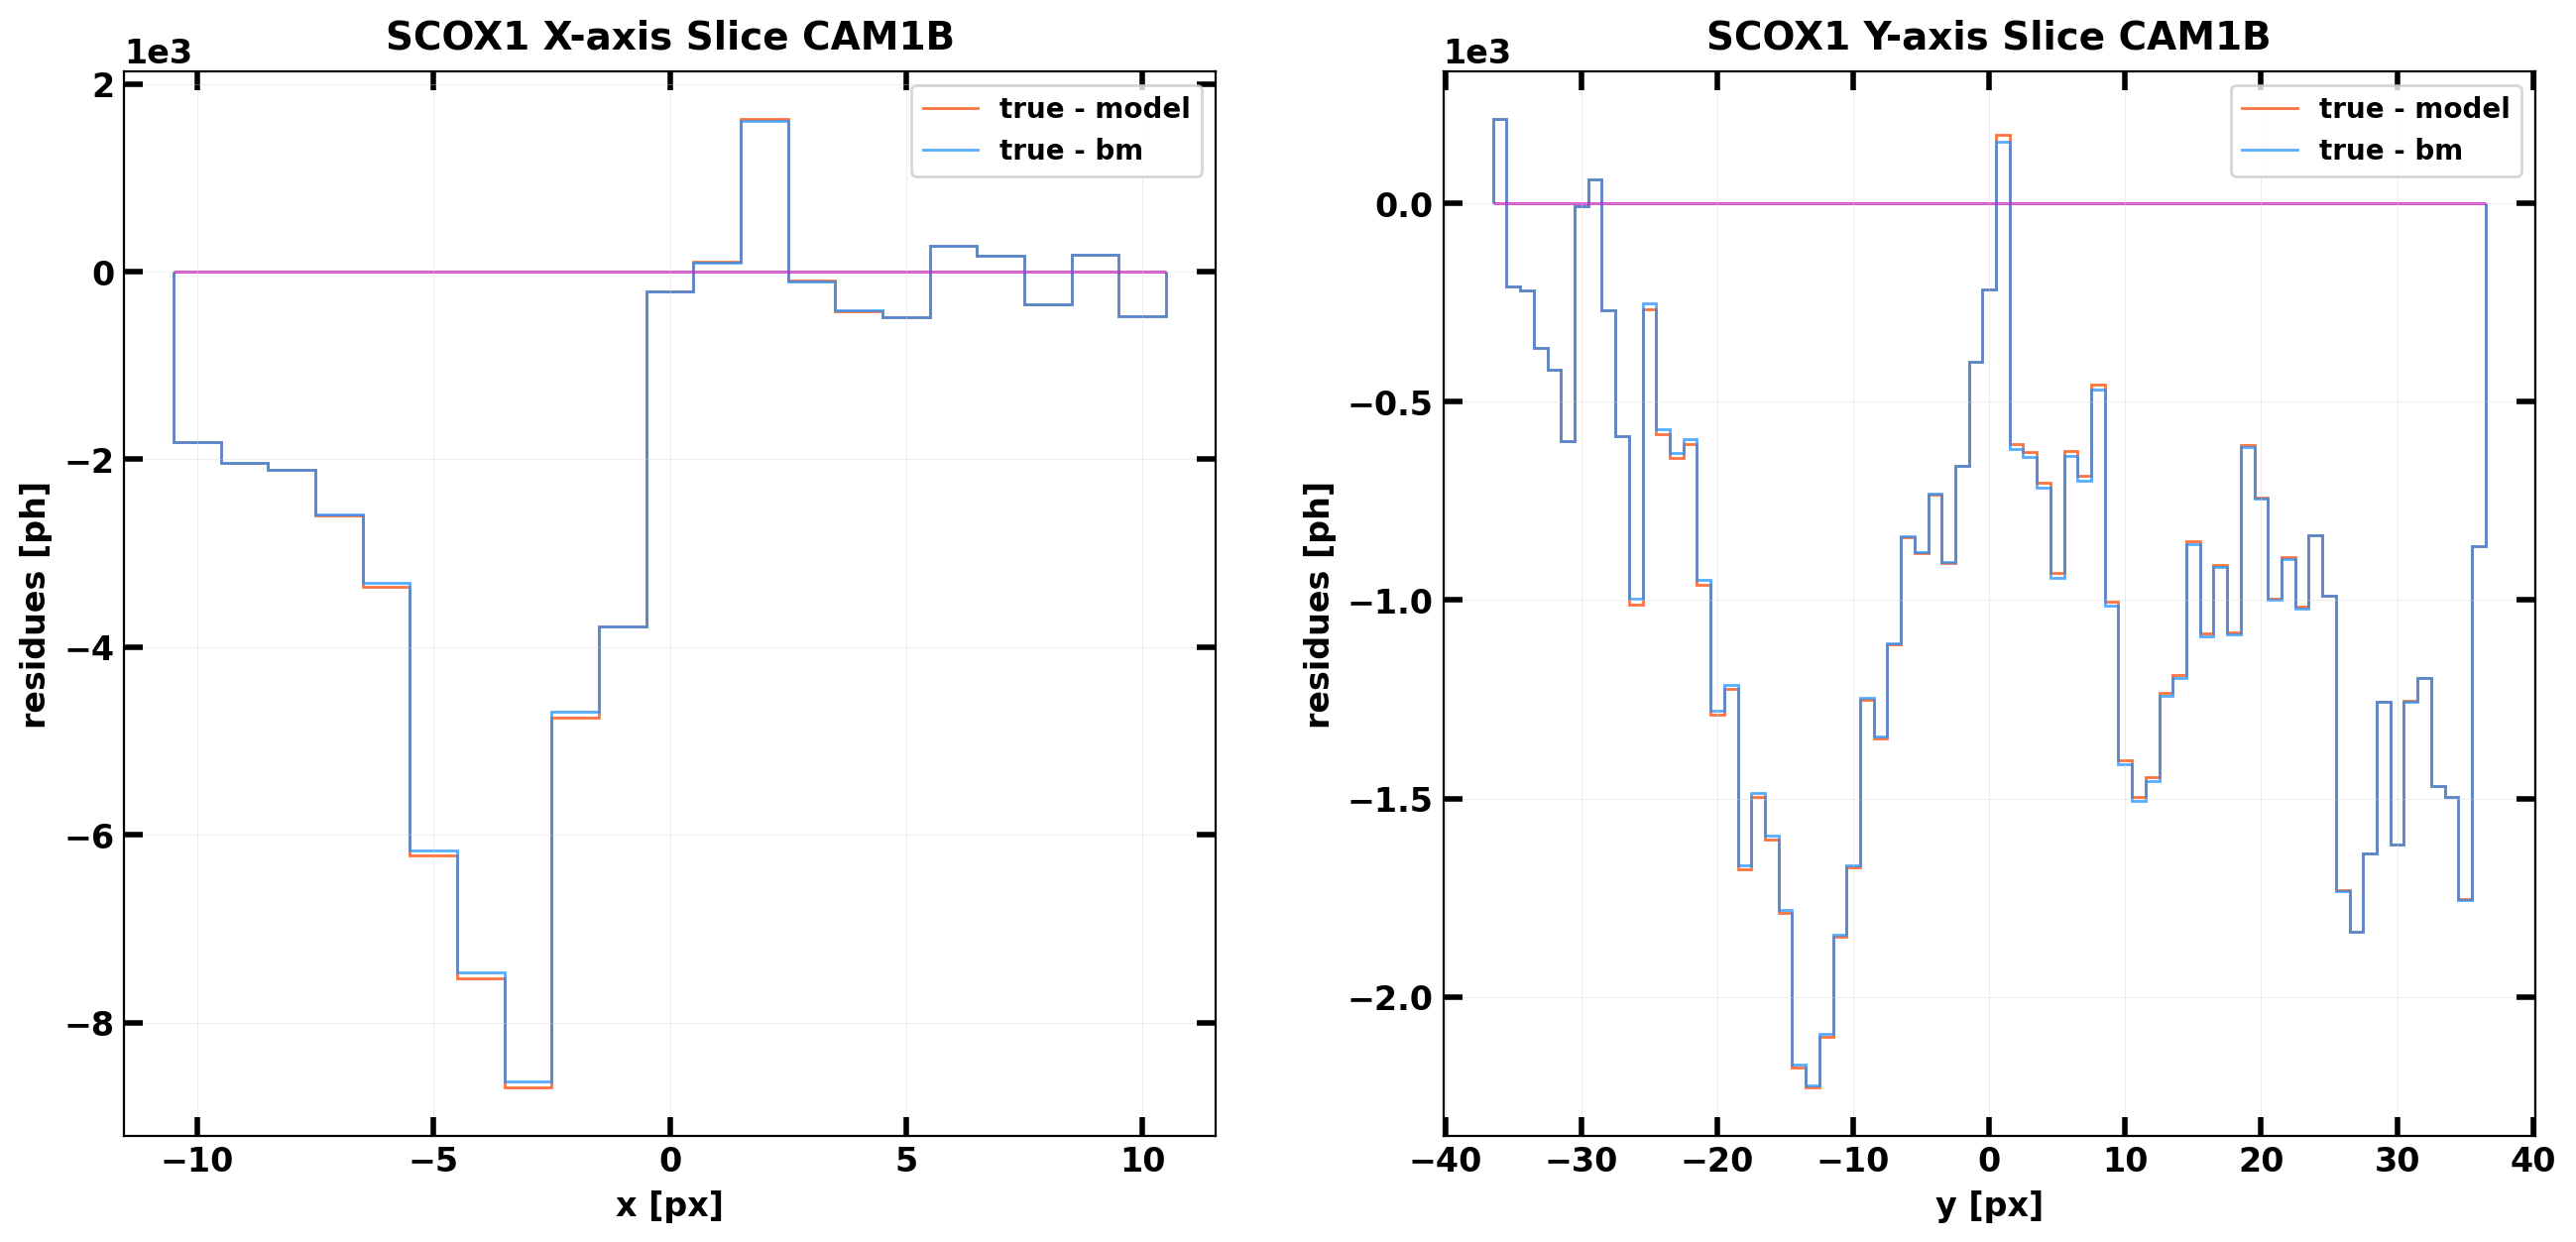

In [4]:
catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])
#coords = tuple(
#    CoordEquatorial(ra, dec) for ra, dec in zip(catalogueB.DLdata['RA'], catalogueB.DLdata['DEC'])
#)
#coords_ = list(coords)
#coords_.pop(idx)
sdlB = ds.get_data(
    filepaths[cam_b][dataset],
    #coords=coords_,
)

detector, _ = count(wfm, sdlB.DLdata)
true_sky = decode(wfm, detector)

sources = extract_catalogue_angular_coords(catalogueB, sdlB, wfm)
lemxSource = sources[(sources['ID'] == source_ID)]

thetax, thetay = np.array(lemxSource['THETAX'])[0], np.array(lemxSource['THETAY'])[0]
print(f'\n{source_ID.upper()} angular coords: {thetax, thetay}\n')
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.009 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6]) + 2e3
#fluence = 1.0 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6]) - 1e3

pxdimy, pxdimx = (
    wfm.specs['mask_deltay'] / wfm.upscale_f.y,
    wfm.specs['mask_deltax'] / wfm.upscale_f.x,
)

alpha = 0.0
lemxSource_model = model_sky(
    camera=wfm,
    shift_x=shiftx + alpha * pxdimx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
lemxSource_bm_model = bm_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_sky = true_sky - lemxSource_model

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.slices_plot(
    sky=(true_sky, lemxSource_model, lemxSource_bm_model),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    labels=('true', 'modelled', 'bm'),
    cameraID=cam_b,
    save_to=savefig_to(save_to, f'skyslice_{source_ID}_{cam_b.upper()}' + '_newpathinmask'),
)
ds.slices_plot(
    sky=(res_sky, true_sky - lemxSource_bm_model, np.zeros(wfm.shape_sky)),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    ylabel='residues [ph]',
    labels=('true - model', 'true - bm', ''),
    cameraID=cam_b,
    save_to=savefig_to(save_to, f'skyslice_res_{source_ID}_{cam_b.upper()}' + '_newpathinmask'),
)
#ds.slices_plot(
#    sky=lemxSource_bm_model - lemxSource_model,
#    pos=(i, j),
#    crp=crp,
#    source=f'{source_ID.upper()} model',
#    ylabel='residues [ph]',
#    labels='bm - fshift',
#    cameraID=cam_b,
#    #save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
#)

In [5]:
shifts_insight(wfm, lemxSource_model, (shiftx, shifty))

SCOX1 shifts: 78.04581352417037, -43.909402530748885
CM shifts: 77.94410801241011, -44.61453476509274
Peak shifts: 78.0, -44.0

CM sigma (x, y): 2.034110235205162, 1.4102644686877142
Peak sigma (x, y): 0.916270483407402, 0.18119493850223023

